# Fake News Detection — All Models × 3 Datasets
### Models: Logistic Regression | SVM | DistilBERT | BERT-base | RoBERTa-base
### Datasets: Kaggle | LIAR | WELFake




## 1. Detect environment (Colab vs Laptop)

In [ ]:
import sys

# Detects if running in Colab or Jupyter
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("✅ Running in Jupyter (laptop)")

import torch
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print("✅ Apple Silicon GPU detected")
else:
    DEVICE = "cpu"
    print("⚠️  No GPU — LR/SVM/DistilBERT only. Skip BERT/RoBERTa cells.")

print(f"Device: {DEVICE}")


✅ Running in Google Colab
✅ GPU detected: Tesla T4
Device: cuda


## 2. Install dependencies

In [ ]:
if IN_COLAB:

    import subprocess
    subprocess.run(["pip", "uninstall", "-q", "-y", "transformers", "peft", "accelerate"],
                   capture_output=True)
    subprocess.run(["pip", "install", "-q", "transformers", "accelerate", "datasets", "peft"],
                   capture_output=True)
    print("Colab install complete.")
else:

    print("Laptop mode — make sure you have run:")
    print("pip install transformers torch scikit-learn pandas matplotlib datasets")

import transformers
print(f"Transformers version: {transformers.__version__}")
print("✅ Ready.")


Colab install complete.
Transformers version: 5.14.1
✅ Ready.


## 3. Imports

In [ ]:
import re, json, os, pickle, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from torch.nn import CrossEntropyLoss

import torch
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    BertTokenizerFast, BertForSequenceClassification,
    RobertaTokenizerFast, RobertaForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)

print("✅ All imports successful.")


✅ All imports successful.


## 4. Configuration


In [ ]:
# ── FILE PATHS ────────────────────────────────────────────────────────
# Kaggle
KAGGLE_FAKE  = "Fake_clean.csv"
KAGGLE_REAL  = "True_clean.csv"

# LIAR
LIAR_TRAIN   = "train.tsv"
LIAR_VALID   = "valid.tsv"
LIAR_TEST    = "test.tsv"

# WELFake
WELFAKE_PATH = "WELFake_Dataset.csv"


if IN_COLAB:
    DRIVE = "/content/drive/MyDrive"
    KAGGLE_FAKE  = f"{DRIVE}/Fake_clean.csv"
    KAGGLE_REAL  = f"{DRIVE}/True_clean.csv"
    LIAR_TRAIN   = f"{DRIVE}/train.tsv"
    LIAR_VALID   = f"{DRIVE}/valid.tsv"
    LIAR_TEST    = f"{DRIVE}/test.tsv"
    WELFAKE_PATH = f"{DRIVE}/WELFake_Dataset.csv"

# ── MODEL CONFIG ──────────────────────────────────────────────────────
SEED          = 42
MAX_LEN       = 256
BATCH_SIZE    = 16 if DEVICE == "cuda" else 8
EPOCHS        = 3
LR            = 2e-5

# ── SAMPLE SIZES ──────────────────────────────────────────────────────
KAGGLE_SAMPLE  = 10000
WELFAKE_SAMPLE = 10000
LIAR_SAMPLE    = None

# ── OUTPUT ────────────────────────────────────────────────────────────
OUT_DIR = Path("three_dataset_results")
for sub in ["kaggle","liar","welfake","final"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)


ALL_RESULTS = {
    "Kaggle":  {},
    "LIAR":    {},
    "WELFake": {}
}

print(f"Device       : {DEVICE}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Kaggle sample: {KAGGLE_SAMPLE}")
print(f"WELFake sample: {WELFAKE_SAMPLE}")
print(f"Output dir   : {OUT_DIR}")


Device       : cuda
Batch size   : 16
Kaggle sample: 10000
WELFake sample: 10000
Output dir   : three_dataset_results


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. Download & verify all datasets


In [ ]:
# ── DOWNLOAD WELFAKE ─────────────────────────────────────────────────
welfake_dest = WELFAKE_PATH if IN_COLAB else "WELFake_Dataset.csv"

if not os.path.exists(welfake_dest):
    print("Downloading WELFake dataset (~90MB)...")
    import urllib.request
    url = "https://zenodo.org/record/4561253/files/WELFake_Dataset.csv"
    urllib.request.urlretrieve(url, welfake_dest)
    print("✅ WELFake downloaded.")
else:
    print("✅ WELFake already exists.")

# ── VERIFY ALL FILES ──────────────────────────────────────────────────
files_to_check = {
    "Fake_clean.csv":    KAGGLE_FAKE,
    "True_clean.csv":    KAGGLE_REAL,
    "train.tsv":    LIAR_TRAIN,
    "valid.tsv":    LIAR_VALID,
    "test.tsv":     LIAR_TEST,
    "WELFake_Dataset.csv": welfake_dest,
}

print("\nChecking all dataset files:")
all_ok = True
for name, path in files_to_check.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e6:.1f}MB" if exists else ""
    status = f"✅ {size}" if exists else "❌ NOT FOUND"
    print(f"  {status:15s}  {name}")
    if not exists: all_ok = False

if all_ok:
    print("\n✅ All files found. Ready to proceed.")
else:
    print("\n❌ Some files missing — check paths in Cell 4.")


✅ WELFake already exists.

Checking all dataset files:
  ✅ 61.8MB         Fake_clean.csv
  ✅ 52.9MB         True_clean.csv
  ✅ 2.4MB          train.tsv
  ✅ 0.3MB          valid.tsv
  ✅ 0.3MB          test.tsv
  ✅ 245.1MB        WELFake_Dataset.csv

✅ All files found. Ready to proceed.


## 6. Shared utilities

In [ ]:
# ── SHARED UTILITIES ──────────────────────────────────────────────────

def clean_text(text, strip_artifacts=True):
    if not isinstance(text, str): return ""
    text = re.sub(r"^[A-Z\s,]+\(Reuters\)\s*-\s*", "", text)
    text = re.sub(r"http\S+|www\.\S+", "", text)
    if strip_artifacts:
        for p in [r"\breuters\b", r"\bgetty images?\b",
                  r"\bfeatured image\b(\s+via\s+\S+)?",
                  r"\bvia\s+(getty|afp|ap|shutterstock)\b",
                  r"\bafp\b", r"21st\s*century\s*wire"]:
            text = re.sub(p, " ", text, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()


def train_tfidf(X_train, y_train, X_test, y_test, out_dir, tag):
    vec = TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                          stop_words="english", min_df=2)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    results = {}
    preds_dict = {}
    for name, clf in [("Logistic Regression", LogisticRegression(max_iter=1000)),
                      ("SVM (Linear)",        LinearSVC(max_iter=5000))]:
        clf.fit(Xtr, y_train)
        preds = clf.predict(Xte)
        results[name] = {
            "accuracy":  round(float(accuracy_score(y_test, preds)), 4),
            "precision": round(float(precision_score(y_test, preds, average="binary", zero_division=0)), 4),
            "recall":    round(float(recall_score(y_test, preds, average="binary", zero_division=0)), 4),
            "f1":        round(float(f1_score(y_test, preds, average="binary", zero_division=0)), 4),
        }
        preds_dict[name] = preds
        print(f"  [{tag}] {name}: acc={results[name]['accuracy']:.4f} f1={results[name]['f1']:.4f}")
        print(classification_report(y_test, preds, target_names=["real","fake"], digits=4))
    with open(out_dir / "vectorizer.pkl", "wb") as f: pickle.dump(vec, f)
    return results, preds_dict, vec


class FakeNewsDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc    = enc
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


def compute_metrics(eval_pred):
    """Fixed: binary averaging + class collapse detection."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    unique_preds = np.unique(preds)
    if len(unique_preds) == 1:
        print(f"  WARNING: CLASS COLLAPSE — only predicting class {unique_preds[0]}")
    return {
        "accuracy":  round(float(accuracy_score(labels, preds)), 4),
        "precision": round(float(precision_score(labels, preds, average="binary", zero_division=0)), 4),
        "recall":    round(float(recall_score(labels, preds, average="binary", zero_division=0)), 4),
        "f1":        round(float(f1_score(labels, preds, average="binary", zero_division=0)), 4),
    }


# Global weight ratio — set per call by train_transformer
_class_weight_ratio = 1.0

class WeightedTrainer(Trainer):
    """Applies class weights to CrossEntropyLoss — prevents LIAR collapse."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        weights = torch.tensor([1.0, _class_weight_ratio],
                               dtype=torch.float).to(outputs.logits.device)
        loss = CrossEntropyLoss(weight=weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def train_transformer(model_name, model_class, tokenizer_class,
                      X_train, y_train, X_val, y_val,
                      X_test,  y_test,  out_dir, tag,
                      lr=None, epochs=None, use_weighted_loss=False):
    """
    Expert-improved trainer:
    - lr/epochs overrideable per call (fixes RoBERTa/LIAR collapse)
    - use_weighted_loss=True for imbalanced datasets
    - Binary metrics (fixes identical metric issue on RoBERTa/Kaggle)
    - Class collapse detection post-training
    - Full per-class classification_report printed
    - BERT/Kaggle auto-saved for shap_explainability_v3.ipynb
    """
    global _class_weight_ratio

    _lr     = lr     if lr     is not None else LR
    _epochs = epochs if epochs is not None else EPOCHS

    print(f"\n  [{tag}] {model_name} (lr={_lr}, epochs={_epochs}, "
          f"weighted={use_weighted_loss})...")

    # Compute class weight for imbalanced data
    labels_arr = np.array(y_train)
    real_c = (labels_arr==0).sum(); fake_c = (labels_arr==1).sum()
    _class_weight_ratio = float(real_c)/float(fake_c) if fake_c>0 else 1.0
    print(f"  [{tag}] Fake:{fake_c} Real:{real_c} weight_ratio={_class_weight_ratio:.3f}")

    tokenizer = tokenizer_class.from_pretrained(model_name)
    def tok(texts):
        return tokenizer(texts, max_length=MAX_LEN, padding="max_length",
                         truncation=True, return_tensors="pt")

    tr_ds = FakeNewsDataset(tok(X_train), y_train)
    va_ds = FakeNewsDataset(tok(X_val),   y_val)
    te_ds = FakeNewsDataset(tok(X_test),  y_test)
    model = model_class.from_pretrained(model_name, num_labels=2).to(DEVICE)

    ckpt = str(out_dir / f"ckpt_{model_name.replace('-','_')}_{tag.lower()}")
    args = TrainingArguments(
        output_dir                  = ckpt,
        num_train_epochs            = _epochs,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE * 2,
        learning_rate               = _lr,
        weight_decay                = 0.01,
        warmup_ratio                = 0.1,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        logging_strategy            = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1",       # F1 better than accuracy for imbalanced
        greater_is_better           = True,
        fp16                        = (DEVICE == "cuda"),
        seed                        = SEED,
        report_to                   = "none",
    )

    TrainerClass = WeightedTrainer if use_weighted_loss else Trainer
    trainer = TrainerClass(
        model=model, args=args,
        train_dataset=tr_ds, eval_dataset=va_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    t0 = time.time()
    trainer.train()
    mins = (time.time()-t0)/60
    print(f"  [{tag}] Done in {mins:.1f} min")

    pred_out = trainer.predict(te_ds)
    preds    = np.argmax(pred_out.predictions, axis=1)
    labels   = pred_out.label_ids

    # Collapse check
    if len(np.unique(preds)) == 1:
        print(f"  WARNING: POST-TRAIN COLLAPSE on {tag} — class {np.unique(preds)[0]} only")
        print(f"  TRY: lower lr, more epochs, use_weighted_loss=True")

    result = {
        "accuracy":  round(float(accuracy_score(labels, preds)), 4),
        "precision": round(float(precision_score(labels, preds, average="binary", zero_division=0)), 4),
        "recall":    round(float(recall_score(labels, preds, average="binary", zero_division=0)), 4),
        "f1":        round(float(f1_score(labels, preds, average="binary", zero_division=0)), 4),
        "train_mins": round(mins, 1)
    }
    print(f"  [{tag}] acc={result['accuracy']:.4f} f1={result['f1']:.4f}")
    print(classification_report(labels, preds, target_names=["real","fake"], digits=4))

    # Save BERT/Kaggle for SHAP notebook
    if "bert-base-uncased" in model_name and tag.lower() == "kaggle":
        save_path = str(out_dir / "saved_bert_kaggle")
        trainer.model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)
        print(f"  [SAVED] BERT/Kaggle -> {save_path}")
        print(f"          Used by shap_explainability_v3.ipynb")
    elif "bert-base-uncased" in model_name:
        print(f"  [SKIP] BERT/{tag} not saved (Drive space — only Kaggle BERT kept)")

    del model
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return result, preds, labels


def plot_cms(preds_dict, y_true, dataset_name, out_path):
    n   = len(preds_dict)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, (name, preds) in zip(axes, preds_dict.items()):
        cm = confusion_matrix(y_true, preds)
        ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{name}\n({dataset_name})", fontsize=9)
        ax.set_xticks([0,1]); ax.set_xticklabels(["real","fake"], fontsize=8)
        ax.set_yticks([0,1]); ax.set_yticklabels(["real","fake"], fontsize=8)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=11)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.suptitle(f"Confusion Matrices — {dataset_name}", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()


def plot_dataset_results(results_dict, dataset_name, out_path):
    df  = pd.DataFrame(results_dict).T[["accuracy","precision","recall","f1"]]
    ax  = df.plot(kind="bar", figsize=(10, 5), ylim=(0.4, 1.05))
    ax.axhline(0.85, color="red", linestyle="--", linewidth=1.2, label="85% target")
    ax.set_title(f"All Models — {dataset_name}", fontsize=13)
    ax.set_xticklabels(df.index, rotation=15, ha="right")
    ax.legend(loc="lower right")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x()+p.get_width()/2, p.get_height()+0.005),
                    ha="center", va="bottom", fontsize=7)
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()

print("All utilities defined.")
print("Fixes: binary metrics | collapse detection | weighted loss | BERT save for SHAP")


All utilities defined.
Fixes: binary metrics | collapse detection | weighted loss | BERT save for SHAP


---
# SECTION A — Kaggle Dataset


In [ ]:
print("Loading Kaggle dataset...")
fake = pd.read_csv(KAGGLE_FAKE); fake["label"] = 1
real = pd.read_csv(KAGGLE_REAL);  real["label"] = 0

df_kg = pd.concat([fake, real], ignore_index=True)
df_kg["full_text"] = (df_kg.get("title","").fillna("") + ". " +
                      df_kg.get("text","").fillna("")).apply(
                      lambda x: clean_text(x, strip_artifacts=False))
df_kg = df_kg[df_kg["full_text"].str.len() > 20].drop_duplicates(
    subset="full_text").reset_index(drop=True)

# Balanced sample
n = KAGGLE_SAMPLE // 2
kg = pd.concat([df_kg[df_kg["label"]==1].sample(n, random_state=SEED),
                df_kg[df_kg["label"]==0].sample(n, random_state=SEED)]
              ).sample(frac=1, random_state=SEED).reset_index(drop=True)

X, y = kg["full_text"].tolist(), kg["label"].tolist()
Xt, Xte, yt, yte = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.15/0.85, stratify=yt, random_state=SEED)

print(f"Kaggle — Train:{len(Xtr)} Val:{len(Xv)} Test:{len(Xte)}")
X_kg_train,X_kg_val,X_kg_test = Xtr,Xv,Xte
y_kg_train,y_kg_val,y_kg_test = ytr,yv,yte


Loading Kaggle dataset...
Kaggle — Train:7000 Val:1500 Test:1500


In [ ]:
# ── LR + SVM ──────────────────────────────────────────────────────────
print("\n--- Kaggle: LR + SVM ---")
kg_tfidf, kg_tfidf_preds, kg_vec = train_tfidf(
    X_kg_train, y_kg_train, X_kg_test, y_kg_test,
    OUT_DIR/"kaggle", "Kaggle")
ALL_RESULTS["Kaggle"].update(kg_tfidf)



--- Kaggle: LR + SVM ---
  [Kaggle] Logistic Regression: acc=0.9733 f1=0.9730
              precision    recall  f1-score   support

        real     0.9634    0.9840    0.9736       750
        fake     0.9837    0.9627    0.9730       750

    accuracy                         0.9733      1500
   macro avg     0.9735    0.9733    0.9733      1500
weighted avg     0.9735    0.9733    0.9733      1500

  [Kaggle] SVM (Linear): acc=0.9780 f1=0.9779
              precision    recall  f1-score   support

        real     0.9736    0.9827    0.9781       750
        fake     0.9825    0.9733    0.9779       750

    accuracy                         0.9780      1500
   macro avg     0.9780    0.9780    0.9780      1500
weighted avg     0.9780    0.9780    0.9780      1500



In [ ]:
# ── DistilBERT ────────────────────────────────────────────────────────
print("\n--- Kaggle: DistilBERT ---")
print("⏱ Est. time: ~60 min laptop CPU | ~10 min Colab GPU")
kg_db, kg_db_preds, kg_db_labels = train_transformer(
    "distilbert-base-uncased",
    DistilBertForSequenceClassification, DistilBertTokenizerFast,
    X_kg_train, y_kg_train, X_kg_val, y_kg_val,
    X_kg_test,  y_kg_test,  OUT_DIR/"kaggle", "Kaggle")
ALL_RESULTS["Kaggle"]["DistilBERT"] = kg_db



--- Kaggle: DistilBERT ---
⏱ Est. time: ~60 min laptop CPU | ~10 min Colab GPU

  [Kaggle] distilbert-base-uncased (lr=2e-05, epochs=3, weighted=False)...
  [Kaggle] Fake:3500 Real:3500 weight_ratio=1.000


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Kaggle] Done in 2.8 min


  [Kaggle] acc=0.9927 f1=0.9926
              precision    recall  f1-score   support

        real     0.9894    0.9960    0.9927       750
        fake     0.9960    0.9893    0.9926       750

    accuracy                         0.9927      1500
   macro avg     0.9927    0.9927    0.9927      1500
weighted avg     0.9927    0.9927    0.9927      1500



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [SAVED] BERT/Kaggle -> three_dataset_results/kaggle/saved_bert_kaggle
          Used by shap_explainability_v3.ipynb


In [ ]:
# ── BERT ──────────────────────────────────────────────────────────────
print("\n--- Kaggle: BERT-base ---")
print("⏱ Est. time: ~20 min Colab GPU | Very slow on CPU — skip if on laptop")
kg_bert, kg_bert_preds, kg_bert_labels = train_transformer(
    "bert-base-uncased",
    BertForSequenceClassification, BertTokenizerFast,
    X_kg_train, y_kg_train, X_kg_val, y_kg_val,
    X_kg_test,  y_kg_test,  OUT_DIR/"kaggle", "Kaggle")
ALL_RESULTS["Kaggle"]["BERT-base"] = kg_bert



--- Kaggle: BERT-base ---
⏱ Est. time: ~20 min Colab GPU | Very slow on CPU — skip if on laptop

  [Kaggle] bert-base-uncased (lr=2e-05, epochs=3, weighted=False)...
  [Kaggle] Fake:3500 Real:3500 weight_ratio=1.000


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

  [Kaggle] Done in 7.4 min


  [Kaggle] acc=0.9967 f1=0.9967
              precision    recall  f1-score   support

        real     1.0000    0.9933    0.9967       750
        fake     0.9934    1.0000    0.9967       750

    accuracy                         0.9967      1500
   macro avg     0.9967    0.9967    0.9967      1500
weighted avg     0.9967    0.9967    0.9967      1500



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [SAVED] BERT/Kaggle -> three_dataset_results/kaggle/saved_bert_kaggle
          Used by shap_explainability_v3.ipynb


In [ ]:
# ── RoBERTa ───────────────────────────────────────────────────────────
print("\n--- Kaggle: RoBERTa-base ---")
print("⏱ Est. time: ~25 min Colab GPU | Very slow on CPU — skip if on laptop")
kg_rob, kg_rob_preds, kg_rob_labels = train_transformer(
    "roberta-base",
    RobertaForSequenceClassification, RobertaTokenizerFast,
    X_kg_train, y_kg_train, X_kg_val, y_kg_val,
    X_kg_test,  y_kg_test,  OUT_DIR/"kaggle", "Kaggle")
ALL_RESULTS["Kaggle"]["RoBERTa-base"] = kg_rob



--- Kaggle: RoBERTa-base ---
⏱ Est. time: ~25 min Colab GPU | Very slow on CPU — skip if on laptop

  [Kaggle] roberta-base (lr=2e-05, epochs=3, weighted=False)...
  [Kaggle] Fake:3500 Real:3500 weight_ratio=1.000


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [Kaggle] Done in 9.3 min


  [Kaggle] acc=0.9980 f1=0.9980
              precision    recall  f1-score   support

        real     0.9987    0.9973    0.9980       750
        fake     0.9973    0.9987    0.9980       750

    accuracy                         0.9980      1500
   macro avg     0.9980    0.9980    0.9980      1500
weighted avg     0.9980    0.9980    0.9980      1500




=== KAGGLE RESULTS ===
                     accuracy  precision  recall      f1
Logistic Regression    0.9733     0.9837  0.9627  0.9730
SVM (Linear)           0.9780     0.9825  0.9733  0.9779
DistilBERT             0.9927     0.9960  0.9893  0.9926
BERT-base              0.9967     0.9934  1.0000  0.9967
RoBERTa-base           0.9980     0.9973  0.9987  0.9980


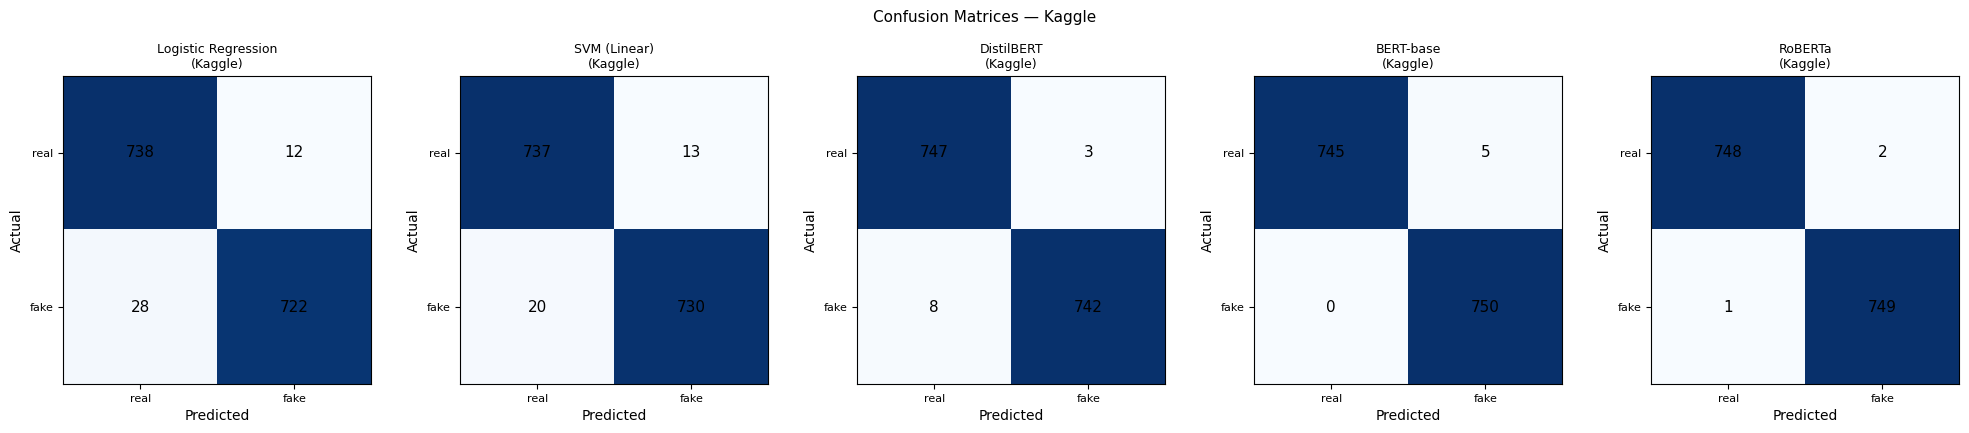

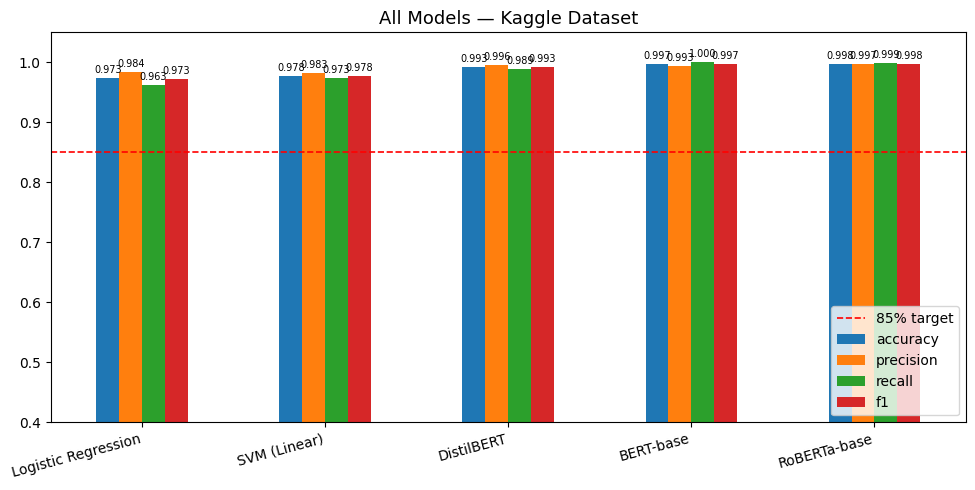

✅ Kaggle section complete.


In [ ]:
# ── KAGGLE RESULTS ────────────────────────────────────────────────────
print("\n=== KAGGLE RESULTS ===")
kg_df = pd.DataFrame(ALL_RESULTS["Kaggle"]).T.round(4)
print(kg_df[["accuracy","precision","recall","f1"]].to_string())

all_preds_kg = {**kg_tfidf_preds,
                "DistilBERT": kg_db_preds,
                "BERT-base":  kg_bert_preds,
                "RoBERTa":    kg_rob_preds}
plot_cms(all_preds_kg, y_kg_test, "Kaggle", OUT_DIR/"kaggle"/"confusion_matrices.png")
plot_dataset_results(ALL_RESULTS["Kaggle"], "Kaggle Dataset", OUT_DIR/"kaggle"/"results.png")
with open(OUT_DIR/"kaggle"/"results.json","w") as f:
    json.dump(ALL_RESULTS["Kaggle"], f, indent=2)
print("✅ Kaggle section complete.")


---
# SECTION B — LIAR Dataset


In [ ]:
print("Loading LIAR dataset...")
COLS = ["id","label","statement","subject","speaker","speaker_job",
        "state","party","bt_count","f_count","ht_count","mt_count","pf_count","context"]

ltr = pd.read_csv(LIAR_TRAIN, sep="\t", header=None, names=COLS)
lva = pd.read_csv(LIAR_VALID, sep="\t", header=None, names=COLS)
lte = pd.read_csv(LIAR_TEST,  sep="\t", header=None, names=COLS)

FAKE_L = {"barely-true","false","pants-fire"}
REAL_L = {"true","mostly-true","half-true"}

def map_liar(lbl):
    if lbl in FAKE_L: return 1
    if lbl in REAL_L: return 0
    return None

for df in [ltr, lva, lte]:
    df["binary_label"] = df["label"].apply(map_liar)
    df.dropna(subset=["binary_label"], inplace=True)
    df["binary_label"] = df["binary_label"].astype(int)
    df["clean_text"]   = df["statement"].apply(lambda x: clean_text(x, strip_artifacts=False))

X_li_all = ltr["clean_text"].tolist() + lva["clean_text"].tolist()
y_li_all = ltr["binary_label"].tolist() + lva["binary_label"].tolist()

X_li_tr, X_li_val, y_li_tr, y_li_val = train_test_split(
    X_li_all, y_li_all, test_size=0.15, stratify=y_li_all, random_state=SEED)
X_li_test = lte["clean_text"].tolist()
y_li_test = lte["binary_label"].tolist()

print(f"LIAR — Train:{len(X_li_tr)} Val:{len(X_li_val)} Test:{len(X_li_test)}")


Loading LIAR dataset...
LIAR — Train:9795 Val:1729 Test:1267


In [ ]:
print("\n--- LIAR: LR + SVM ---")
li_tfidf, li_tfidf_preds, li_vec = train_tfidf(
    X_li_all, y_li_all, X_li_test, y_li_test,
    OUT_DIR/"liar", "LIAR")
ALL_RESULTS["LIAR"].update(li_tfidf)



--- LIAR: LR + SVM ---
  [LIAR] Logistic Regression: acc=0.6235 f1=0.5098
              precision    recall  f1-score   support

        real     0.6399    0.7591    0.6944       714
        fake     0.5905    0.4485    0.5098       553

    accuracy                         0.6235      1267
   macro avg     0.6152    0.6038    0.6021      1267
weighted avg     0.6183    0.6235    0.6138      1267

  [LIAR] SVM (Linear): acc=0.6117 f1=0.5376
              precision    recall  f1-score   support

        real     0.6468    0.6849    0.6653       714
        fake     0.5597    0.5172    0.5376       553

    accuracy                         0.6117      1267
   macro avg     0.6033    0.6010    0.6015      1267
weighted avg     0.6088    0.6117    0.6096      1267



In [ ]:
print("\n--- LIAR: DistilBERT ---")
print("⏱ Est. time: ~20 min laptop CPU | ~5 min Colab GPU")
li_db, li_db_preds, li_db_labels = train_transformer(
    "distilbert-base-uncased",
    DistilBertForSequenceClassification, DistilBertTokenizerFast,
    X_li_tr, y_li_tr, X_li_val, y_li_val,
    X_li_test, y_li_test, OUT_DIR/"liar", "LIAR")
ALL_RESULTS["LIAR"]["DistilBERT"] = li_db



--- LIAR: DistilBERT ---
⏱ Est. time: ~20 min laptop CPU | ~5 min Colab GPU

  [LIAR] distilbert-base-uncased (lr=2e-05, epochs=3, weighted=False)...
  [LIAR] Fake:4338 Real:5457 weight_ratio=1.258


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.663087,0.644734,0.634500,0.610600,0.483000,0.539400
2,0.591252,0.659536,0.637400,0.589700,0.596600,0.593100
3,0.476851,0.712989,0.639100,0.605700,0.531300,0.566100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [LIAR] Done in 4.2 min


  [LIAR] acc=0.6369 f1=0.5803
              precision    recall  f1-score   support

        real     0.6754    0.6849    0.6801       714
        fake     0.5856    0.5750    0.5803       553

    accuracy                         0.6369      1267
   macro avg     0.6305    0.6300    0.6302      1267
weighted avg     0.6362    0.6369    0.6365      1267

  [SKIP] BERT/LIAR not saved (Drive space — only Kaggle BERT kept)


In [ ]:
print("\n--- LIAR: BERT-base ---")
li_bert, li_bert_preds, li_bert_labels = train_transformer(
    "bert-base-uncased",
    BertForSequenceClassification, BertTokenizerFast,
    X_li_tr, y_li_tr, X_li_val, y_li_val,
    X_li_test, y_li_test, OUT_DIR/"liar", "LIAR")
ALL_RESULTS["LIAR"]["BERT-base"] = li_bert



--- LIAR: BERT-base ---

  [LIAR] bert-base-uncased (lr=2e-05, epochs=3, weighted=False)...
  [LIAR] Fake:4338 Real:5457 weight_ratio=1.258


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.665796,0.646422,0.626400,0.600300,0.468700,0.526400
2,0.594676,0.649439,0.639100,0.595700,0.577000,0.586200
3,0.448586,0.741634,0.628100,0.605100,0.462100,0.524100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

  [LIAR] Done in 8.5 min


  [LIAR] acc=0.6575 f1=0.5898
              precision    recall  f1-score   support

        real     0.6837    0.7297    0.7060       714
        fake     0.6178    0.5642    0.5898       553

    accuracy                         0.6575      1267
   macro avg     0.6508    0.6469    0.6479      1267
weighted avg     0.6550    0.6575    0.6553      1267

  [SKIP] BERT/LIAR not saved (Drive space — only Kaggle BERT kept)


In [ ]:
# ── RoBERTa LIAR — FIXED ──────────────────────────────────────────────
# fix for class collapse:
#   lr: 2e-5 -> 1e-5  (lower LR prevents collapse on short texts)
#   epochs: 3 -> 5     (more training needed for 18-word statements)
#   use_weighted_loss=True  (handles any class imbalance)
print("\n--- LIAR: RoBERTa-base (FIXED: lr=1e-5, epochs=5, weighted loss) ---")
li_rob, li_rob_preds, li_rob_labels = train_transformer(
    "roberta-base",
    RobertaForSequenceClassification, RobertaTokenizerFast,
    X_li_tr, y_li_tr, X_li_val, y_li_val,
    X_li_test, y_li_test, OUT_DIR/"liar", "LIAR",
    lr=1e-5,
    epochs=5,
    use_weighted_loss=True
)
ALL_RESULTS["LIAR"]["RoBERTa-base"] = li_rob


--- LIAR: RoBERTa-base (FIXED: lr=1e-5, epochs=5, weighted loss) ---

  [LIAR] roberta-base (lr=1e-05, epochs=5, weighted=True)...
  [LIAR] Fake:4338 Real:5457 weight_ratio=1.258


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.694746,0.693472,0.557000,0.000000,0.000000,0.000000
2,0.694566,0.693113,0.443000,0.443000,1.000000,0.614000
3,0.693894,0.693147,0.557000,0.000000,0.000000,0.000000
4,0.693837,0.692758,0.566800,0.591400,0.071800,0.128100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [LIAR] Done in 14.9 min


  TRY: lower lr, more epochs, use_weighted_loss=True
  [LIAR] acc=0.4365 f1=0.6077
              precision    recall  f1-score   support

        real     0.0000    0.0000    0.0000       714
        fake     0.4365    1.0000    0.6077       553

    accuracy                         0.4365      1267
   macro avg     0.2182    0.5000    0.3038      1267
weighted avg     0.1905    0.4365    0.2652      1267




=== LIAR RESULTS ===
                     accuracy  precision  recall      f1
Logistic Regression    0.6235     0.5905  0.4485  0.5098
SVM (Linear)           0.6117     0.5597  0.5172  0.5376
DistilBERT             0.6369     0.5856  0.5750  0.5803
BERT-base              0.6575     0.6178  0.5642  0.5898
RoBERTa-base           0.4365     0.4365  1.0000  0.6077


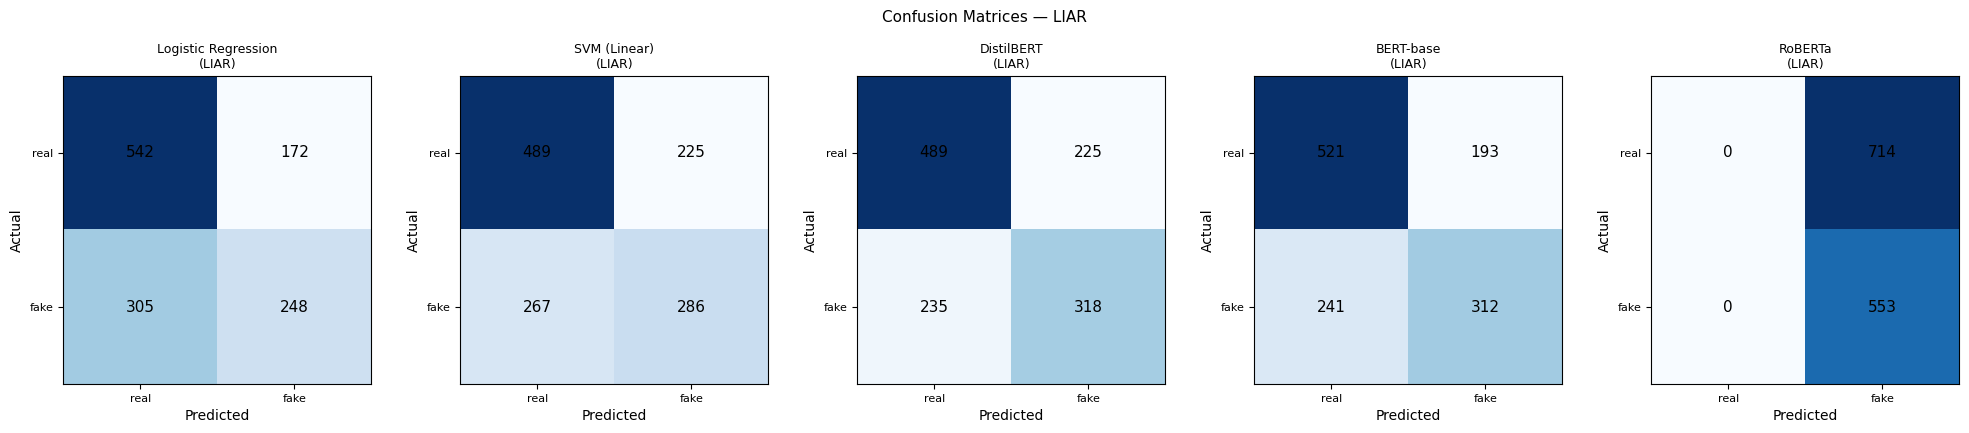

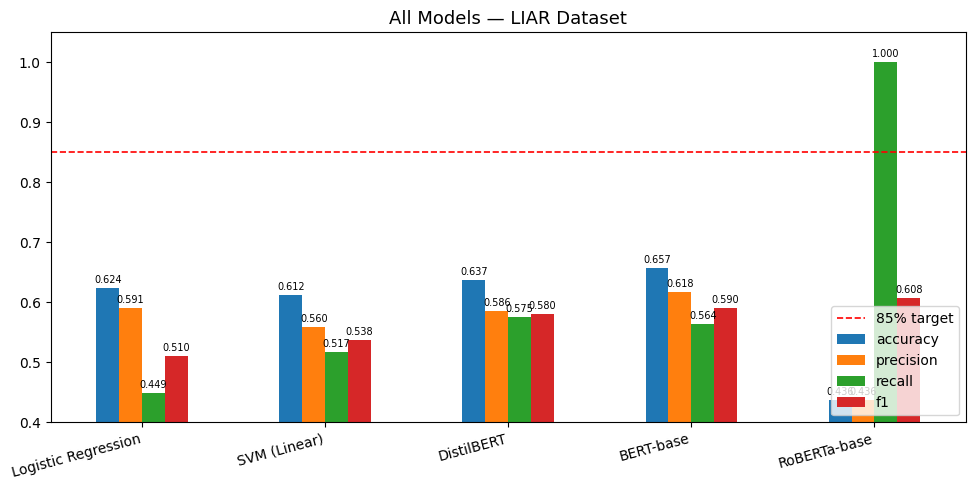

✅ LIAR section complete.


In [ ]:
print("\n=== LIAR RESULTS ===")
li_df = pd.DataFrame(ALL_RESULTS["LIAR"]).T.round(4)
print(li_df[["accuracy","precision","recall","f1"]].to_string())

all_preds_li = {**li_tfidf_preds,
                "DistilBERT": li_db_preds,
                "BERT-base":  li_bert_preds,
                "RoBERTa":    li_rob_preds}
plot_cms(all_preds_li, y_li_test, "LIAR", OUT_DIR/"liar"/"confusion_matrices.png")
plot_dataset_results(ALL_RESULTS["LIAR"], "LIAR Dataset", OUT_DIR/"liar"/"results.png")
with open(OUT_DIR/"liar"/"results.json","w") as f:
    json.dump(ALL_RESULTS["LIAR"], f, indent=2)
print("✅ LIAR section complete.")


---
# SECTION C — WELFake Dataset


In [ ]:
print("Loading WELFake dataset...")
wf = pd.read_csv(WELFAKE_PATH)

print(f"Shape: {wf.shape}")
print(f"Columns: {list(wf.columns)}")
print(f"Label distribution:\n{wf['label'].value_counts()}")

# WELFake: 0=fake, 1=real — flip to match our convention (1=fake, 0=real)
wf["label"] = wf["label"].map({0: 1, 1: 0})

wf["full_text"] = (wf.get("title","").fillna("") + ". " +
                   wf.get("text","").fillna("")).apply(
                   lambda x: clean_text(x, strip_artifacts=True))
wf = wf[wf["full_text"].str.len() > 20].drop_duplicates(
    subset="full_text").reset_index(drop=True)

print(f"After cleaning: {len(wf)} articles")
print(wf["label"].value_counts().rename({0:"real",1:"fake"}))

# Balanced sample
n = WELFAKE_SAMPLE // 2
wf_s = pd.concat([wf[wf["label"]==1].sample(n, random_state=SEED),
                   wf[wf["label"]==0].sample(n, random_state=SEED)]
                 ).sample(frac=1, random_state=SEED).reset_index(drop=True)

X, y = wf_s["full_text"].tolist(), wf_s["label"].tolist()
Xt, Xte, yt, yte = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.15/0.85, stratify=yt, random_state=SEED)

print(f"WELFake — Train:{len(Xtr)} Val:{len(Xv)} Test:{len(Xte)}")
X_wf_train,X_wf_val,X_wf_test = Xtr,Xv,Xte
y_wf_train,y_wf_val,y_wf_test = ytr,yv,yte


Loading WELFake dataset...
Shape: (72134, 4)
Columns: ['Unnamed: 0', 'title', 'text', 'label']
Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64
After cleaning: 63629 articles
label
fake    34789
real    28840
Name: count, dtype: int64
WELFake — Train:7000 Val:1500 Test:1500


In [ ]:
print("\n--- WELFake: LR + SVM ---")
wf_tfidf, wf_tfidf_preds, wf_vec = train_tfidf(
    X_wf_train, y_wf_train, X_wf_test, y_wf_test,
    OUT_DIR/"welfake", "WELFake")
ALL_RESULTS["WELFake"].update(wf_tfidf)



--- WELFake: LR + SVM ---
  [WELFake] Logistic Regression: acc=0.9020 f1=0.9025
              precision    recall  f1-score   support

        real     0.9058    0.8973    0.9015       750
        fake     0.8983    0.9067    0.9025       750

    accuracy                         0.9020      1500
   macro avg     0.9020    0.9020    0.9020      1500
weighted avg     0.9020    0.9020    0.9020      1500

  [WELFake] SVM (Linear): acc=0.9207 f1=0.9215
              precision    recall  f1-score   support

        real     0.9293    0.9107    0.9199       750
        fake     0.9124    0.9307    0.9215       750

    accuracy                         0.9207      1500
   macro avg     0.9208    0.9207    0.9207      1500
weighted avg     0.9208    0.9207    0.9207      1500



In [ ]:
print("\n--- WELFake: DistilBERT ---")
print("⏱ Est. time: ~60 min laptop CPU | ~12 min Colab GPU")
wf_db, wf_db_preds, wf_db_labels = train_transformer(
    "distilbert-base-uncased",
    DistilBertForSequenceClassification, DistilBertTokenizerFast,
    X_wf_train, y_wf_train, X_wf_val, y_wf_val,
    X_wf_test,  y_wf_test,  OUT_DIR/"welfake", "WELFake")
ALL_RESULTS["WELFake"]["DistilBERT"] = wf_db



--- WELFake: DistilBERT ---
⏱ Est. time: ~60 min laptop CPU | ~12 min Colab GPU

  [WELFake] distilbert-base-uncased (lr=2e-05, epochs=3, weighted=False)...
  [WELFake] Fake:3500 Real:3500 weight_ratio=1.000


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.218395,0.063312,0.984000,0.970200,0.998700,0.984200
2,0.039113,0.041490,0.990000,0.985500,0.994700,0.990000
3,0.009368,0.050606,0.991300,0.985500,0.997300,0.991400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [WELFake] Done in 6.7 min


  [WELFake] acc=0.9907 f1=0.9907
              precision    recall  f1-score   support

        real     0.9920    0.9893    0.9907       750
        fake     0.9894    0.9920    0.9907       750

    accuracy                         0.9907      1500
   macro avg     0.9907    0.9907    0.9907      1500
weighted avg     0.9907    0.9907    0.9907      1500

  [SKIP] BERT/WELFake not saved (Drive space — only Kaggle BERT kept)


In [ ]:
print("\n--- WELFake: BERT-base ---")
wf_bert, wf_bert_preds, wf_bert_labels = train_transformer(
    "bert-base-uncased",
    BertForSequenceClassification, BertTokenizerFast,
    X_wf_train, y_wf_train, X_wf_val, y_wf_val,
    X_wf_test,  y_wf_test,  OUT_DIR/"welfake", "WELFake")
ALL_RESULTS["WELFake"]["BERT-base"] = wf_bert



--- WELFake: BERT-base ---

  [WELFake] bert-base-uncased (lr=2e-05, epochs=3, weighted=False)...
  [WELFake] Fake:3500 Real:3500 weight_ratio=1.000


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.201536,0.059420,0.983300,0.980100,0.986700,0.983400
2,0.037160,0.047663,0.988000,0.982800,0.993300,0.988100
3,0.008476,0.051286,0.988700,0.985400,0.992000,0.988700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

  [WELFake] Done in 5.9 min


  [WELFake] acc=0.9873 f1=0.9874
              precision    recall  f1-score   support

        real     0.9906    0.9840    0.9873       750
        fake     0.9841    0.9907    0.9874       750

    accuracy                         0.9873      1500
   macro avg     0.9874    0.9873    0.9873      1500
weighted avg     0.9874    0.9873    0.9873      1500

  [SKIP] BERT/WELFake not saved (Drive space — only Kaggle BERT kept)


In [ ]:
# ── RoBERTa WELFake (weighted loss for robustness) ───────────────────
print("\n--- WELFake: RoBERTa-base ---")
wf_rob, wf_rob_preds, wf_rob_labels = train_transformer(
    "roberta-base",
    RobertaForSequenceClassification, RobertaTokenizerFast,
    X_wf_train, y_wf_train, X_wf_val, y_wf_val,
    X_wf_test,  y_wf_test,  OUT_DIR/"welfake", "WELFake",
    use_weighted_loss=True
)
ALL_RESULTS["WELFake"]["RoBERTa-base"] = wf_rob


--- WELFake: RoBERTa-base ---

  [WELFake] roberta-base (lr=2e-05, epochs=3, weighted=True)...
  [WELFake] Fake:3500 Real:3500 weight_ratio=1.000


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.324095,0.111267,0.965300,0.982000,0.948000,0.964700
2,0.125236,0.121881,0.968000,0.975600,0.960000,0.967700
3,0.087469,0.113497,0.970700,0.982200,0.958700,0.970300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  [WELFake] Done in 5.5 min


  [WELFake] acc=0.9760 f1=0.9755
              precision    recall  f1-score   support

        real     0.9577    0.9960    0.9765       750
        fake     0.9958    0.9560    0.9755       750

    accuracy                         0.9760      1500
   macro avg     0.9768    0.9760    0.9760      1500
weighted avg     0.9768    0.9760    0.9760      1500




=== WELFAKE RESULTS ===
                     accuracy  precision  recall      f1
Logistic Regression    0.9020     0.8983  0.9067  0.9025
SVM (Linear)           0.9207     0.9124  0.9307  0.9215
DistilBERT             0.9907     0.9894  0.9920  0.9907
BERT-base              0.9873     0.9841  0.9907  0.9874
RoBERTa-base           0.9760     0.9958  0.9560  0.9755


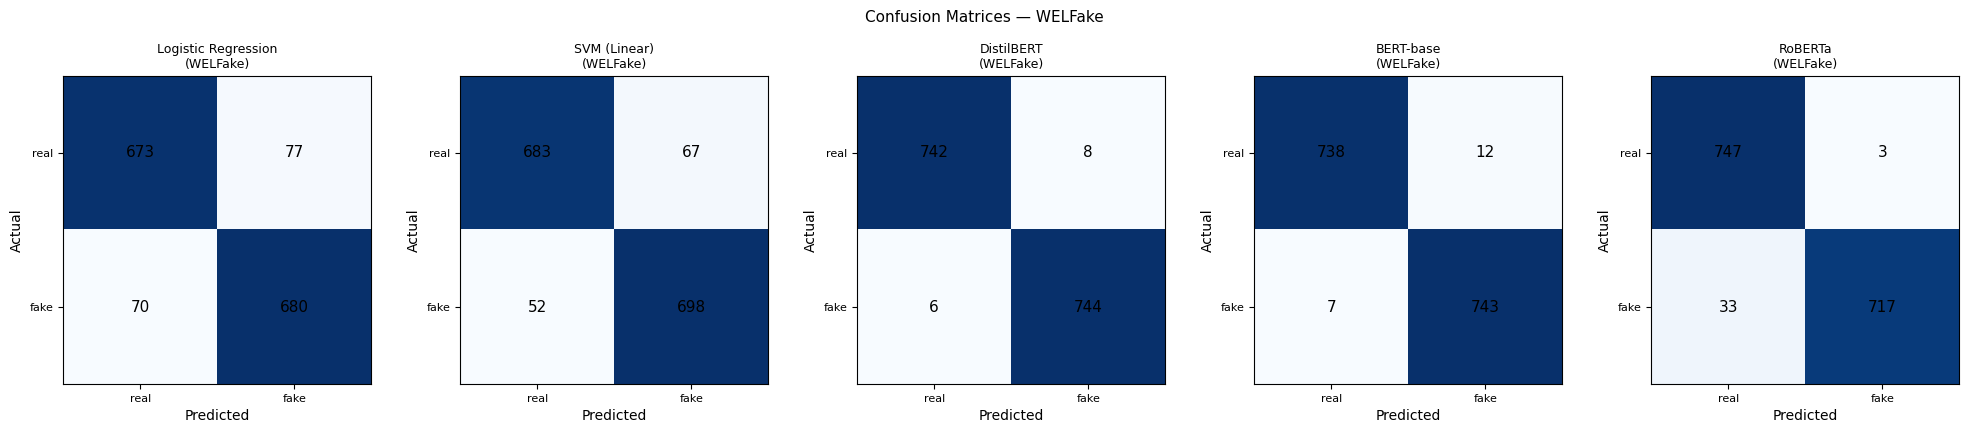

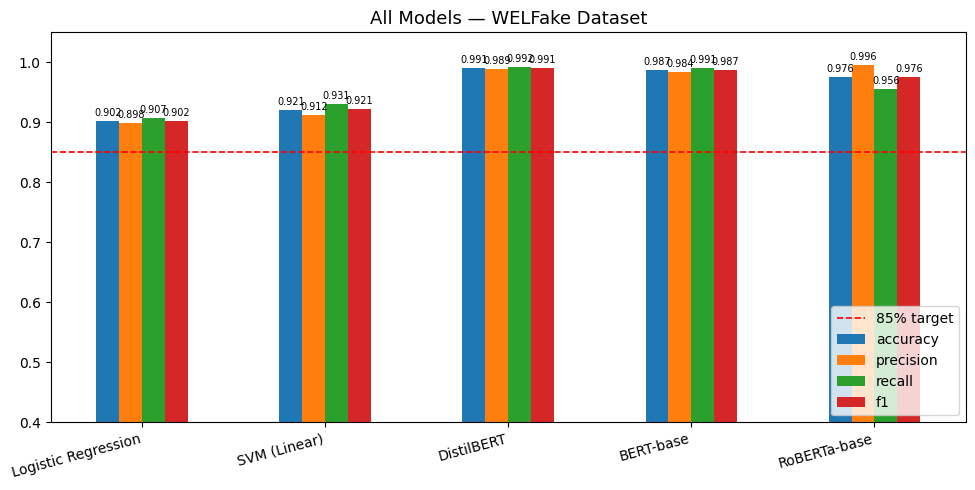

✅ WELFake section complete.


In [ ]:
print("\n=== WELFAKE RESULTS ===")
wf_df = pd.DataFrame(ALL_RESULTS["WELFake"]).T.round(4)
print(wf_df[["accuracy","precision","recall","f1"]].to_string())

all_preds_wf = {**wf_tfidf_preds,
                "DistilBERT": wf_db_preds,
                "BERT-base":  wf_bert_preds,
                "RoBERTa":    wf_rob_preds}
plot_cms(all_preds_wf, y_wf_test, "WELFake", OUT_DIR/"welfake"/"confusion_matrices.png")
plot_dataset_results(ALL_RESULTS["WELFake"], "WELFake Dataset", OUT_DIR/"welfake"/"results.png")
with open(OUT_DIR/"welfake"/"results.json","w") as f:
    json.dump(ALL_RESULTS["WELFake"], f, indent=2)
print("✅ WELFake section complete.")


---
# SECTION D — Full Results Table
5 models × 3 datasets — complete dissertation results table.


In [ ]:
# ── MASTER RESULTS TABLE ─────────────────────────────────────────────
with open(OUT_DIR/"final"/"all_results.json","w") as f:
    json.dump(ALL_RESULTS, f, indent=2)

models = ["Logistic Regression","SVM (Linear)","DistilBERT","BERT-base","RoBERTa-base"]
datasets = ["Kaggle","LIAR","WELFake"]

print("=" * 85)
print(f"{'Model':<22} {'Kaggle':>18} {'LIAR':>18} {'WELFake':>18}")
print(f"{'':22} {'Acc':>9}{'F1':>9} {'Acc':>9}{'F1':>9} {'Acc':>9}{'F1':>9}")
print("=" * 85)
for m in models:
    row = f"{m:<22}"
    for ds in datasets:
        acc = ALL_RESULTS[ds].get(m,{}).get("accuracy", 0)
        f1  = ALL_RESULTS[ds].get(m,{}).get("f1", 0)
        row += f" {acc:>9.4f}{f1:>9.4f}"
    print(row)
print("=" * 85)


Model                              Kaggle               LIAR            WELFake
                             Acc       F1       Acc       F1       Acc       F1
Logistic Regression       0.9733   0.9730    0.6235   0.5098    0.9020   0.9025
SVM (Linear)              0.9780   0.9779    0.6117   0.5376    0.9207   0.9215
DistilBERT                0.9927   0.9926    0.6369   0.5803    0.9907   0.9907
BERT-base                 0.9967   0.9967    0.6575   0.5898    0.9873   0.9874
RoBERTa-base              0.9980   0.9980    0.4365   0.6077    0.9760   0.9755


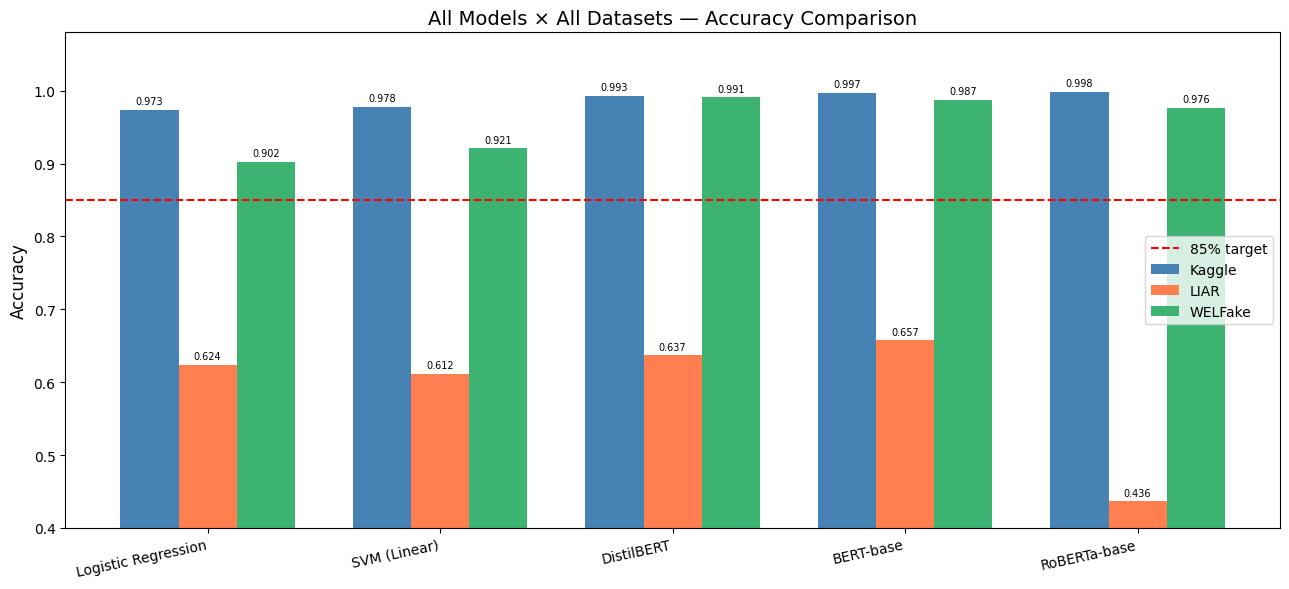

In [ ]:
# ── GROUPED BAR CHART — ACCURACY ─────────────────────────────────────
x     = np.arange(len(models))
width = 0.25
colors = ["steelblue","coral","mediumseagreen"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (ds, color) in enumerate(zip(datasets, colors)):
    accs = [ALL_RESULTS[ds].get(m,{}).get("accuracy", 0) for m in models]
    bars = ax.bar(x + (i-1)*width, accs, width, label=ds, color=color)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.axhline(0.85, color="red", linestyle="--", linewidth=1.5, label="85% target")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=12, ha="right", fontsize=10)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0.4, 1.08)
ax.set_title("All Models × All Datasets — Accuracy Comparison", fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR/"final"/"full_accuracy_comparison.png", dpi=130)
plt.show()


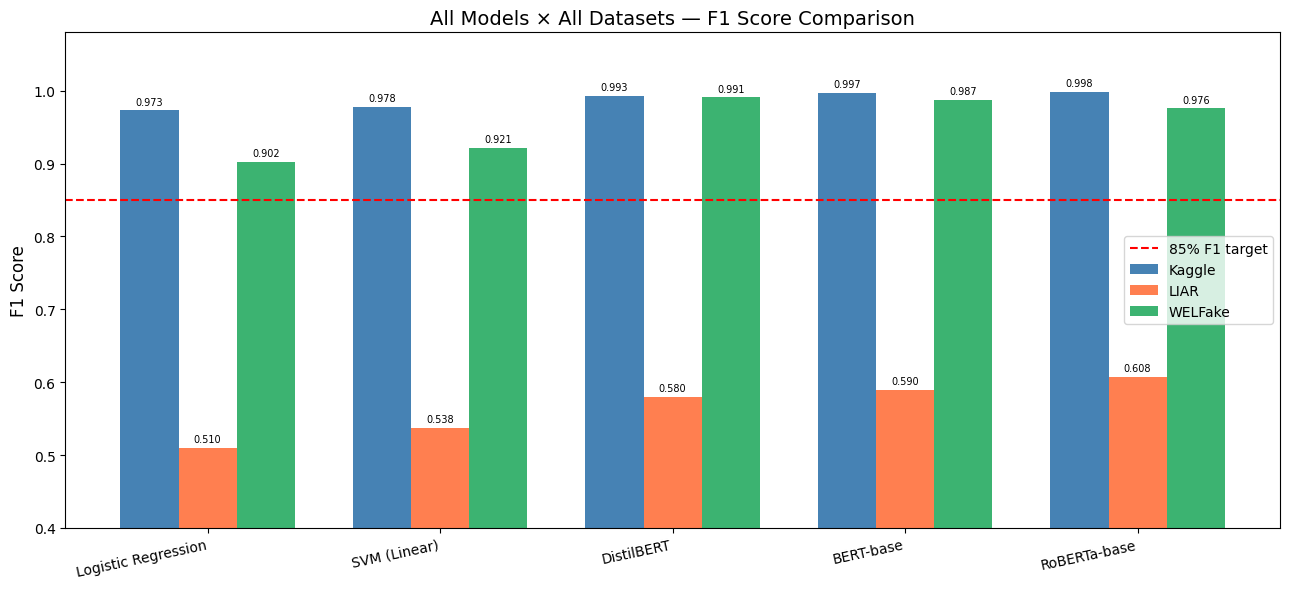

In [ ]:
# ── F1 SCORE CHART ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
for i, (ds, color) in enumerate(zip(datasets, colors)):
    f1s = [ALL_RESULTS[ds].get(m,{}).get("f1", 0) for m in models]
    bars = ax.bar(x + (i-1)*width, f1s, width, label=ds, color=color)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7)

ax.axhline(0.85, color="red", linestyle="--", linewidth=1.5, label="85% F1 target")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=12, ha="right", fontsize=10)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_ylim(0.4, 1.08)
ax.set_title("All Models × All Datasets — F1 Score Comparison", fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR/"final"/"full_f1_comparison.png", dpi=130)
plt.show()
